# 01 — Data Exploration & Single-EV Validation

This notebook:
1. Loads the three core datasets (NTS trips, EV fleet, charging stations)
2. Shows basic statistics and distributions
3. Runs a single-EV one-day simulation and plots the SOC profile

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mobility as em

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100


ModuleNotFoundError: No module named 'mobility'

## 1. Load Data

In [ ]:
trips, fleet, stations = em.load_all()
print(f'NTS Trips:          {trips.shape}')
print(f'EV Fleet:           {fleet.shape}')
print(f'Charging Stations:  {stations.shape}')

NTS Trips:          (415714, 12)
EV Fleet:           (1582682, 13)
Charging Stations:  (26959, 7)


## 2. NTS Trip Statistics

Mean trips per person-day: 2.75
Median: 2, Max: 16


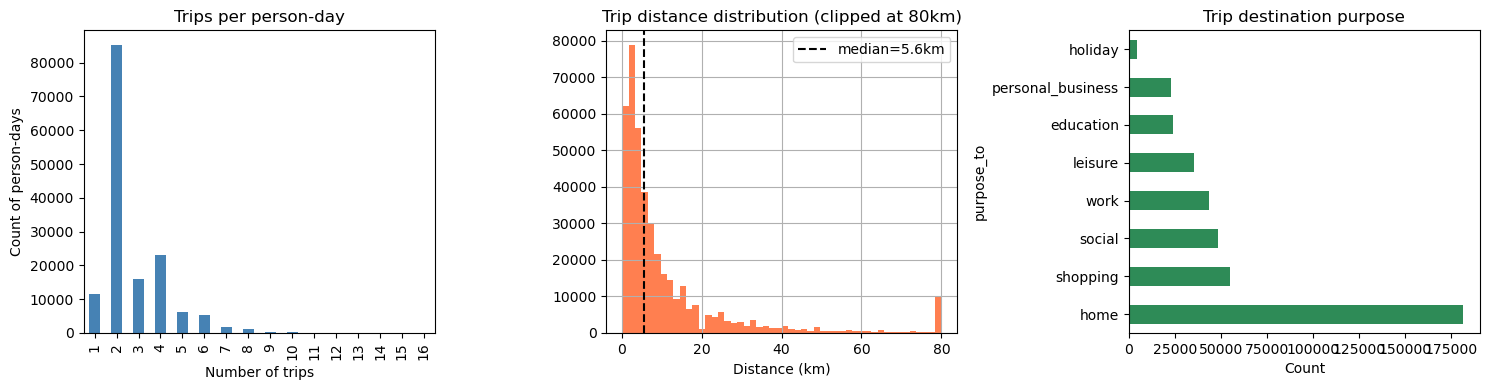

In [ ]:
# Trips per person-day
trips_per_day = trips.groupby(['IndividualID', 'DayID']).size()
print(f'Mean trips per person-day: {trips_per_day.mean():.2f}')
print(f'Median: {trips_per_day.median():.0f}, Max: {trips_per_day.max()}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of trips per day
trips_per_day.value_counts().sort_index().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Trips per person-day')
axes[0].set_xlabel('Number of trips')
axes[0].set_ylabel('Count of person-days')

# Distance distribution
trips['distance_km'].clip(upper=80).hist(bins=50, ax=axes[1], color='coral')
axes[1].set_title('Trip distance distribution (clipped at 80km)')
axes[1].set_xlabel('Distance (km)')
axes[1].axvline(trips['distance_km'].median(), color='k', ls='--', label=f'median={trips["distance_km"].median():.1f}km')
axes[1].legend()

# Purpose distribution
trips['purpose_to'].value_counts().plot.barh(ax=axes[2], color='seagreen')
axes[2].set_title('Trip destination purpose')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

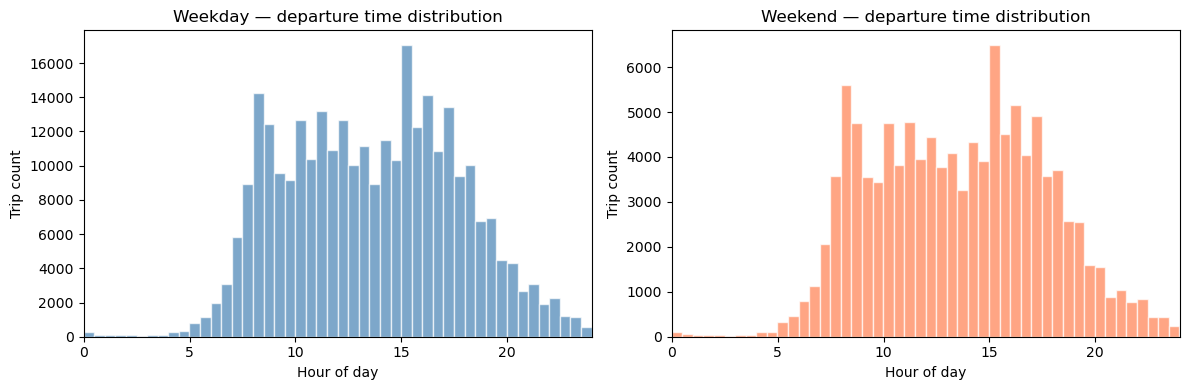

          mean_distance_km  median_distance_km  total_trips
day_type                                                   
weekday              13.07                5.63       302930
weekend              13.64                5.95       112784


In [ ]:
# Weekday vs Weekend comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, dt in enumerate(['weekday', 'weekend']):
    sub = trips[trips['day_type'] == dt]
    tpd = sub.groupby(['IndividualID', 'DayID']).size()
    axes[i].hist(sub['departure_time'].dropna(), bins=48, alpha=0.7,
                 color='steelblue' if dt == 'weekday' else 'coral',
                 edgecolor='white')
    axes[i].set_title(f'{dt.title()} — departure time distribution')
    axes[i].set_xlabel('Hour of day')
    axes[i].set_ylabel('Trip count')
    axes[i].set_xlim(0, 24)

plt.tight_layout()
plt.show()

# Summary table
summary = trips.groupby('day_type').agg(
    mean_distance_km=('distance_km', 'mean'),
    median_distance_km=('distance_km', 'median'),
    total_trips=('distance_km', 'count'),
).round(2)
print(summary)

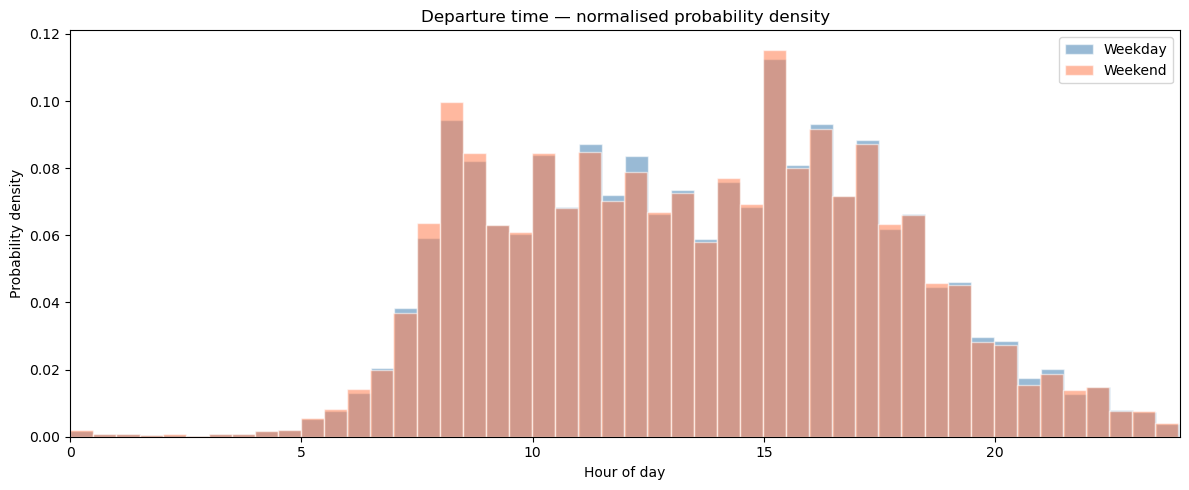

In [ ]:
# Normalised probability density comparison
fig, ax = plt.subplots(figsize=(12, 5))

for dt, color, label in [('weekday', 'steelblue', 'Weekday'),
                          ('weekend', 'coral', 'Weekend')]:
    sub = trips[trips['day_type'] == dt]['departure_time'].dropna()
    ax.hist(sub, bins=48, density=True, alpha=0.55, color=color,
            edgecolor='white', label=label)

ax.set_title('Departure time — normalised probability density')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Probability density')
ax.set_xlim(0, 24)
ax.legend()
plt.tight_layout()
plt.show()

## 3. EV Fleet Overview

Total EVs: 1,582,682
Unique models: 387
Battery capacity: count    1582455.0
mean          69.1
std           28.3
min            5.5
25%           59.0
50%           66.5
75%           79.0
max          621.0
Name: battery_capacity_kwh, dtype: float64


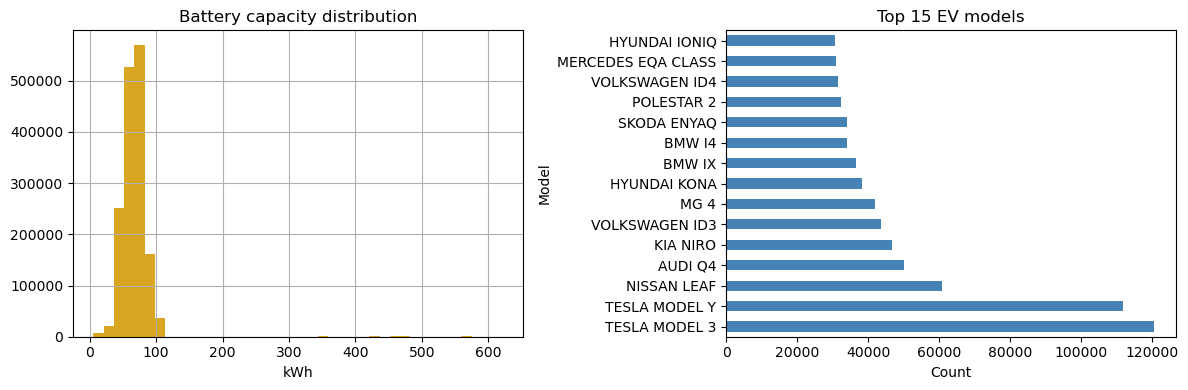

In [ ]:
print(f'Total EVs: {len(fleet):,}')
print(f'Unique models: {fleet["Model"].nunique()}')
print(f'Battery capacity: {fleet["battery_capacity_kwh"].describe().round(1)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fleet['battery_capacity_kwh'].dropna().hist(bins=40, ax=axes[0], color='goldenrod')
axes[0].set_title('Battery capacity distribution')
axes[0].set_xlabel('kWh')

fleet['Model'].value_counts().head(15).plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 EV models')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 4. Charging Station Overview

Total stations: 26,959
With LSOA: 26,937



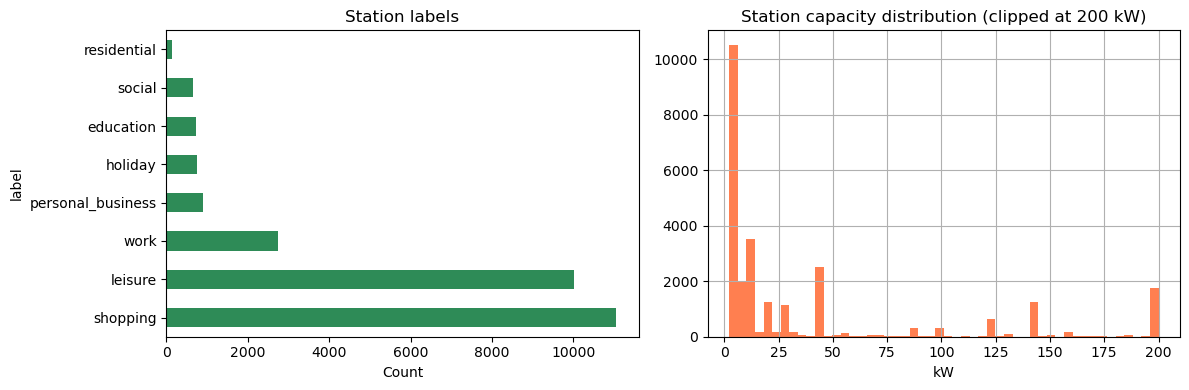

In [ ]:
print(f'Total stations: {len(stations):,}')
print(f'With LSOA: {stations["lsoa_code"].notna().sum():,}')
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stations['label'].value_counts().plot.barh(ax=axes[0], color='seagreen')
axes[0].set_title('Station labels')
axes[0].set_xlabel('Count')

stations['TotalCapacity_kW'].clip(upper=200).hist(bins=50, ax=axes[1], color='coral')
axes[1].set_title('Station capacity distribution (clipped at 200 kW)')
axes[1].set_xlabel('kW')

plt.tight_layout()
plt.show()

## 5. Single-EV Simulation (1 day)

In [ ]:
import random
random.seed(42)
np.random.seed(42)

def _hm(h):
    """Decimal hours → HH:MM string."""
    hh = int(h)
    mm = int(round((h - hh) * 60))
    if mm == 60:
        hh += 1; mm = 0
    return f'{hh:02d}:{mm:02d}'

# Build trip chain pools
pools = em.build_trip_chain_pools(trips)
print(f'Weekday chains: {len(pools["weekday"]):,}')
print(f'Weekend chains: {len(pools["weekend"]):,}')

# Pick one EV
ev_row = fleet.iloc[0]
mini_fleet = fleet.iloc[:1].copy()
print(f'\nTest EV: {ev_row["EV_ID"]}, {ev_row["Model"]}')
print(f'  Battery: {ev_row["battery_capacity_kwh"]} kWh')
print(f'  AC charger: {ev_row["ac_power_kw"]} kW')

# Assign trip chain
schedules = em.assign_chains_to_fleet(mini_fleet, pools, num_days=1)

# Match stations
em.match_stations_for_fleet(schedules, mini_fleet, stations)

# Show schedule
ev_id = ev_row['EV_ID']
sched = schedules[ev_id][0]
print(f'\n--- Day 0 Schedule ---')
print(f'Trips ({len(sched.trips)}):')
for t in sched.trips:
    print(f'  {_hm(t.departure_time)}→{_hm(t.arrival_time)}  '
          f'{t.distance_km:5.1f}km  {t.origin_purpose}→{t.destination_purpose}  '
          f'E={t.energy_consumed_kwh:.2f}kWh')
print(f'Parking ({len(sched.parking_events)}):')
for p in sched.parking_events:
    print(f'  {_hm(p.start_time)}→{_hm(p.end_time)}  at {p.location_purpose:<20s}  '
          f'charge={p.can_charge}  P={p.charge_power_kw:.1f}kW')

Weekday chains: 109,756
Weekend chains: 41,676

Test EV: cars_1, TESLA MODEL 3
  Battery: 75.0 kWh
  AC charger: 11.0 kW

--- Day 0 Schedule ---
Trips (2):
  11:33→11:51   24.1km  home→leisure  E=3.43kWh
  17:56→18:24   24.1km  leisure→home  E=3.43kWh
Parking (3):
  00:00→11:33  at home                  charge=True  P=7.0kW
  11:51→17:56  at leisure               charge=True  P=11.0kW
  18:24→24:00  at home                  charge=True  P=7.0kW


In [ ]:
# Simulate
battery_kwh = ev_row['battery_capacity_kwh']
soc_profile, load_profile, soc_end = em.simulate_single_day(
    sched, battery_kwh, soc_start=1.0
)

STEP = 0.25
hours = np.arange(96) * STEP  # step-start times: 0, 0.25, ..., 23.75

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# SOC profile — plot end-of-step SOC at step-end times, prepend initial SOC at t=0
soc_hours = np.append(0.0, hours + STEP)        # 0, 0.25, ..., 24.0
soc_vals  = np.append(100.0, soc_profile * 100) # soc_start=100% at t=0
ax1.plot(soc_hours, soc_vals, 'b-', linewidth=2)
ax1.set_ylabel('SOC (%)')
ax1.set_title(f'Single-EV Simulation: {ev_row["Model"]} ({battery_kwh} kWh)')
ax1.set_ylim(0, 105)
ax1.axhline(20, color='r', ls='--', alpha=0.5, label='20% threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Shade trips and parking — snap to 15-min grid to align with discrete steps
for t in sched.trips:
    dep = np.floor(t.departure_time / STEP) * STEP
    arr = np.ceil(t.arrival_time   / STEP) * STEP
    ax1.axvspan(dep, arr, alpha=0.15, color='red', label='_')
for p in sched.parking_events:
    if p.can_charge:
        dep = np.floor(p.start_time / STEP) * STEP
        arr = np.ceil(p.end_time    / STEP) * STEP
        ax1.axvspan(dep, arr, alpha=0.1, color='green', label='_')

# Load profile — step='post' keeps each bin's power constant over its full 15-min interval
ax2.fill_between(hours, load_profile, step='post', alpha=0.7, color='orange')
ax2.set_ylabel('Charging Power (kW)')
ax2.set_xlabel('Hour of Day')
ax2.set_xlim(0, 24)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'SOC end: {soc_end*100:.1f}%')
print(f'Min SOC: {soc_profile.min()*100:.1f}%')
print(f'Peak load: {load_profile.max():.1f} kW')
print(f'Total energy charged: {load_profile.sum() * 0.25:.2f} kWh')
print(f'Total energy consumed: {sum(t.energy_consumed_kwh for t in sched.trips):.2f} kWh')


## 6. Validation Checks

In [ ]:
# Energy balance check
total_consumed = sum(t.energy_consumed_kwh for t in sched.trips)
total_charged = load_profile.sum() * 0.25
soc_change_kwh = (soc_end - 1.0) * battery_kwh
balance = total_charged - total_consumed - soc_change_kwh

print('=== Energy Balance ===')
print(f'Total consumed (trips): {total_consumed:.2f} kWh')
print(f'Total charged:          {total_charged:.2f} kWh')
print(f'SOC change (kWh):       {soc_change_kwh:.2f} kWh')
print(f'Balance residual:       {balance:.4f} kWh (should be ~0)')
print()

# SOC bounds check
assert soc_profile.min() >= 0, 'SOC went below 0!'
assert soc_profile.max() <= 1.0 + 1e-6, 'SOC exceeded 100%!'
print('SOC bounds: OK (0% ≤ SOC ≤ 100%)')

# Chronological check
for i in range(len(sched.trips) - 1):
    t1, t2 = sched.trips[i], sched.trips[i+1]
    assert t1.arrival_time <= t2.departure_time + 0.01, \
        f'Trip overlap: trip {i} ends at {t1.arrival_time}, trip {i+1} starts at {t2.departure_time}'
print('Trip chronology: OK')

print('\n✓ All validation checks passed.')

=== Energy Balance ===
Total consumed (trips): 6.86 kWh
Total charged:          6.64 kWh
SOC change (kWh):       -0.21 kWh
Balance residual:       -0.0000 kWh (should be ~0)

SOC bounds: OK (0% ≤ SOC ≤ 100%)
Trip chronology: OK

✓ All validation checks passed.
